<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/UDel_DSPS_Final_JBieber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHYS 461 - Final Exam - Jarrod Bieber

## 12/12/2025
---

The resources that I used for this assignment primarily consist of the DSPS lecture slides, as well as some Gemini and the website geeksforgeeks.org (for acquiring additional information on my chosen prediction models). Wherever possible, I adapted the code/techniques that were utilized in the homework assignments and labs.

I start by pip installing the special package that I need to read in the MAGIC data.

In [ ]:
pip install ucimlrepo

I import all the libraries that I need.

Pandas for tables, numpy for numbers, pyplot for plotting, os for file management,

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# for importing UCI's data
from ucimlrepo import fetch_ucirepo

# for data exploration
import seaborn as sns
from missingno import matrix

# for building the models
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler # For scaling the numerical features -> (0 to 1)
from sklearn.ensemble import RandomForestClassifier
from tensorflow import keras
from keras import layers
from keras.callbacks import EarlyStopping


# for evaluating model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Task 1: Acquire the Data
---

The following is the UCI provided code for importing the MAGIC dataset in Python. It splits the data into 'X' (features) and 'y' (targets) dataframes, then prints information about the variables as was shared in Prof. Bianco's GitHub instructions.

In [ ]:
# fetch dataset
magic_gamma_telescope = fetch_ucirepo(id=159)

# data (as pandas dataframes)
X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

# metadata
print(magic_gamma_telescope.metadata)

# variable information
print(magic_gamma_telescope.variables)

{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

## Task 2: Explore the Data
---

Here I will explore the data, for both the features (X) and the targets (y) dataframes.

First I check the Head, which gives the first 5 rows. We just want to do this to get a quick early look at things, to make sure something isn't horribly wrong with the data structure. From the head, it looks like the first y-entries are classified as signals.

In [ ]:
X.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


In [ ]:
y.head()

,class
0,g
1,g
2,g
3,g
4,g


Next I print the Tail, which shows the last 5 rows. Still no horrendous issues to report. Interestingly, the results of the y-targets are flipped from how they were in the head, with the last 5 y-entries here being classified as hadrons.

In [ ]:
X.tail()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174


In [ ]:
y.tail()

,class
19015,h
19016,h
19017,h
19018,h
19019,h


The `describe()` function provides statistics about the data.

X is numerical data and so it's describe() function shows the number of entries, the min/max values, the mean/median values, and the standard deviation.

Y is categorical data, and its describe() function shows the number of entries, the number of unique entries (there are indeed only two classes), the top (most frequent) class, and that class's frequency. We see that about 2/3rds of the y-entries are classified as signal, and the remaining 1/3rd are the background hadrons. This means that the target variable is **imbalanced**. I will have to stratify (split by class) my data when I do the train test split for my prediction models. Otherwise the models may become biased towards predicting that a detection is a gamma-ray (the larger class), even when it is not a gamma-ray.

In [ ]:
X.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000,19020.000000
mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026
std,42.364855,18.346056,0.472599,0.182813,0.110511,59.206062,51.000118,20.827439,26.103621,74.731787
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.336000,11.863800,2.477100,0.235800,0.128475,-20.586550,-12.842775,-10.849375,5.547925,142.492250
50%,37.147700,17.139900,2.739600,0.354150,0.196500,4.013050,15.314100,0.666200,17.679500,191.851450
75%,70.122175,24.739475,3.101600,0.503700,0.285225,24.063700,35.837800,10.946425,45.883550,240.563825
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


In [ ]:
y.describe()

,class
count,19020
unique,2
top,g
freq,12332


The `shape` attribute just gives us the dimensions (rows, columns) of our dataframes. This is another way to verify that the row numbers are consistent between X and y datasets (kind of important), and the column numbers are as we expect.

In [ ]:
X.shape

(19020, 10)

In [ ]:
y.shape

(19020, 1)

We specifically examine the dataset columns some more with the `columns` attribute, which prints the name of each column for our X and y dataframes, and states their collective data type. 'object' means mixed data types, or Strings.

In [ ]:
X.columns

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist'],
      dtype='object')

In [ ]:
y.columns

Index(['class'], dtype='object')

The `info()` function summarizes information about the data, including column names, non-null count, data type, and the size of the dataframes in memory. It appears that all values for all 19,020 entries are populated with a value, and are not null. So far so good.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
dtypes: float64(10)
memory usage: 1.5 MB


In [ ]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   19020 non-null  object
dtypes: object(1)
memory usage: 148.7+ KB


We can create a visualization of the lack of null values in our X feature dataset using the `matrix()` class from the `missingno` library. Not the most especially useful plot in this case, but we did it in class, and we might as well show that it is an option.

<Axes: >

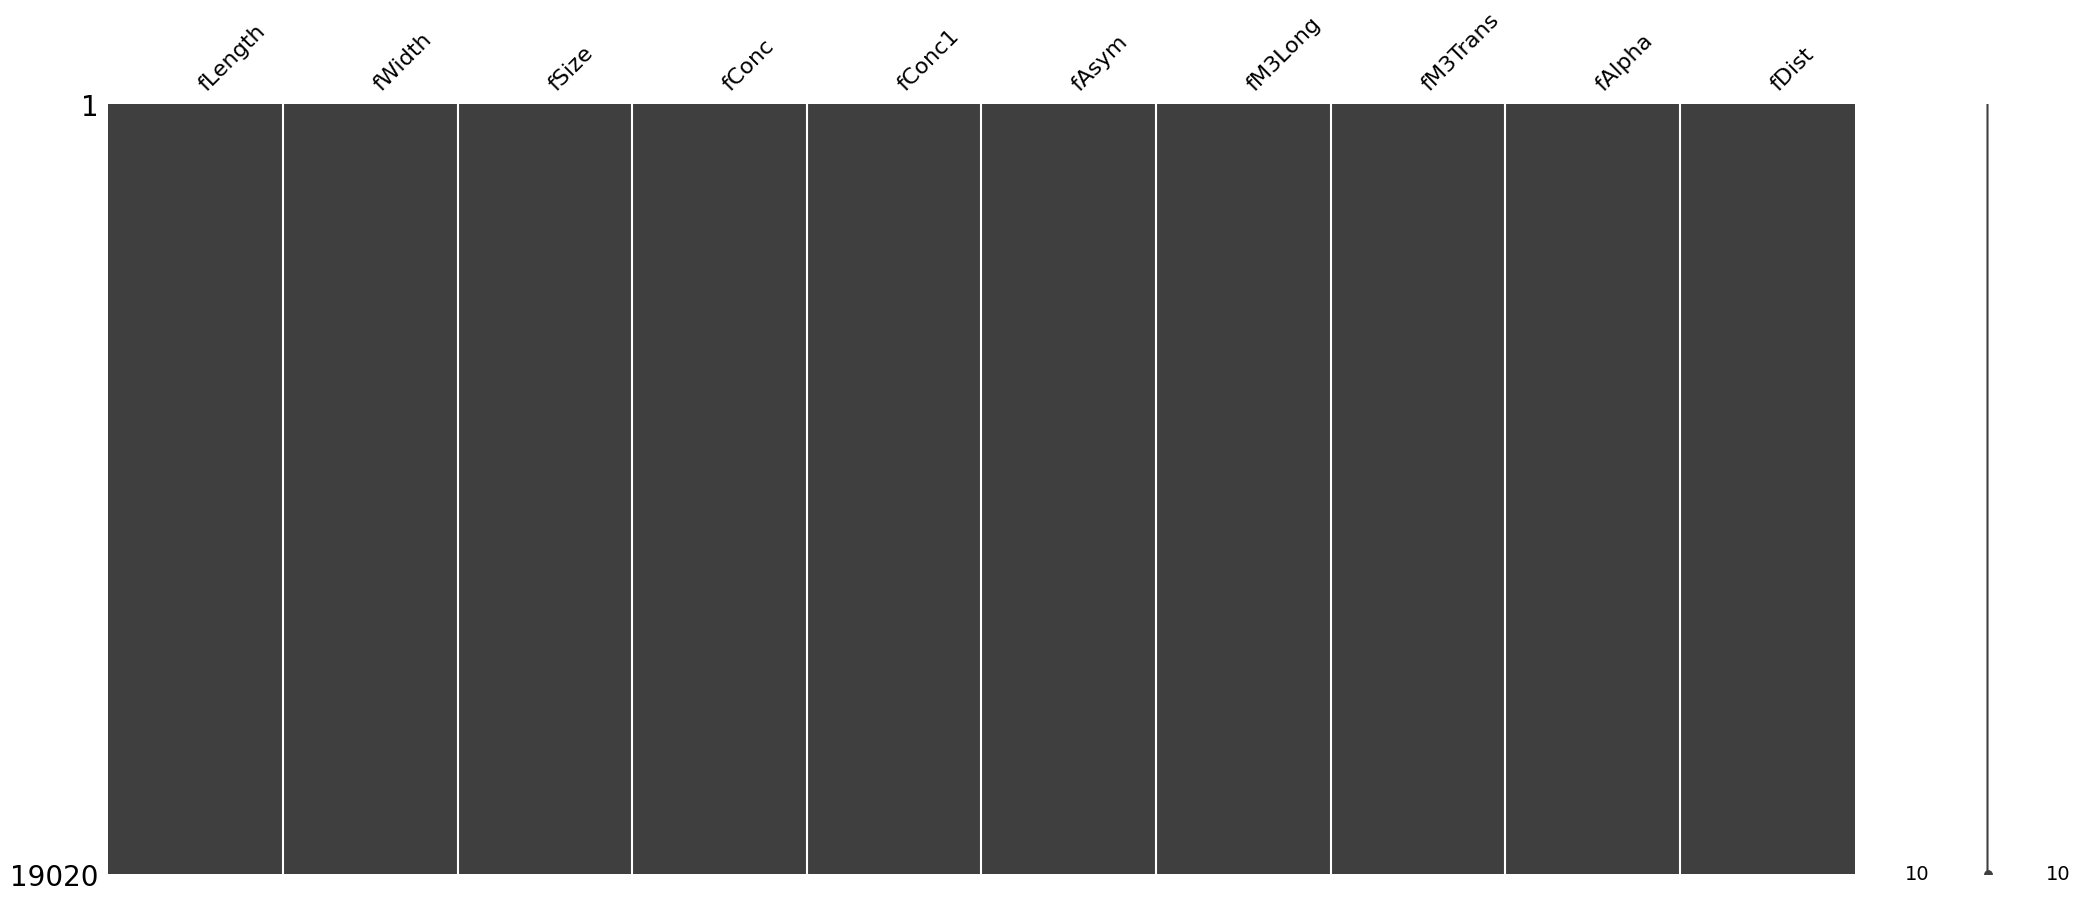

In [ ]:
matrix(X)

Figure 1: A missing number matrix for the X (features) of the MAGIC dataset. Each column represents a feature of the data, and there are 10 features total. Each row represents an individual detection/observation. A lack of white gaps/lines in the plot indicates that all datapoints are present, none are missing.

We can make a correlation matrix for the X features to show how each feature is linearly related to every other feature. This is important as it can sometimes have implications for feature importance. The values in the matrix can range from -1 (perfect negative correlation) to 1 (perfect positive correlation). Here we are comparing only numerical (float64) data types. This step is not applicable to the y dataframe because that dataset has only one column.

First we display the first 5 rows of the X correlation matrix with `head()`, then we generate a plot of the matrix with a Seaborn color mapping.

In [ ]:
correlation_matrix_X = X.corr(numeric_only=True)
display(correlation_matrix_X.head())

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
fLength,1.000000,0.770512,0.702454,-0.630999,-0.598145,-0.368556,-0.119747,0.013389,-0.008777,0.418466
fWidth,0.770512,1.000000,0.717517,-0.609779,-0.581141,-0.266961,-0.176234,0.039744,0.066061,0.336816
fSize,0.702454,0.717517,1.000000,-0.850850,-0.808835,-0.159863,0.095157,0.015455,-0.186675,0.437041
fConc,-0.630999,-0.609779,-0.850850,1.000000,0.976412,0.112272,-0.121899,-0.011294,0.235272,-0.328332
fConc1,-0.598145,-0.581141,-0.808835,0.976412,1.000000,0.100159,-0.118769,-0.010966,0.229799,-0.304625


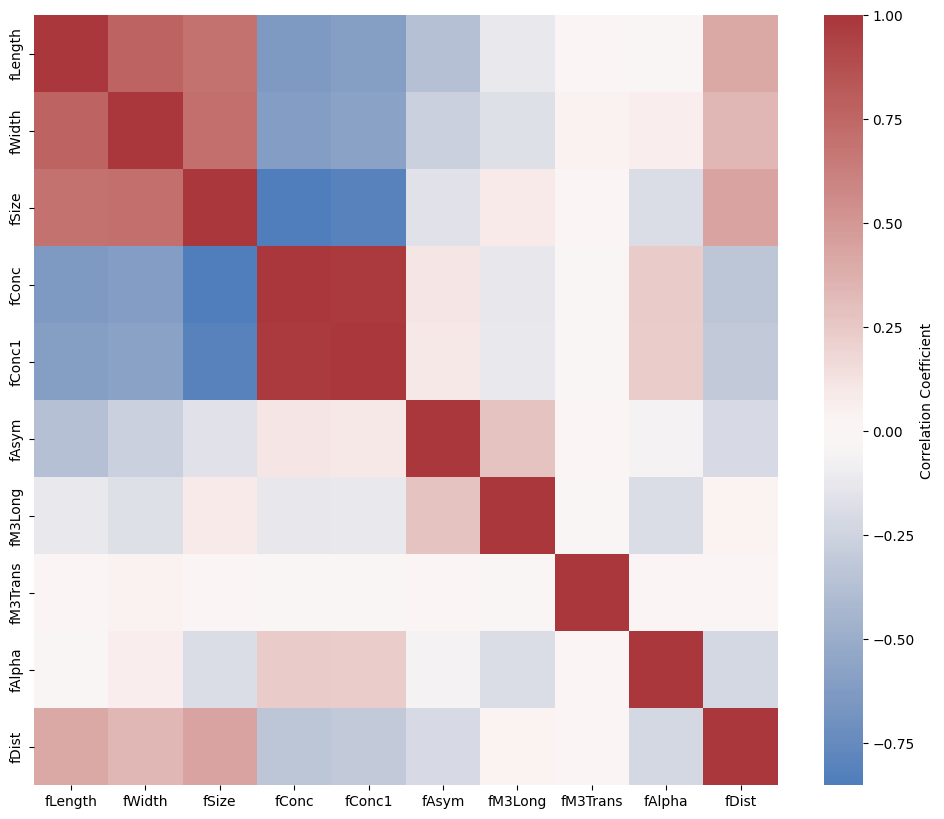

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_X, cmap='vlag', annot=False, cbar_kws={'label': 'Correlation Coefficient'}, center=0)
#plt.title('Correlation Matrix of MAGIC Data')
plt.show()

Figure 2: A correlation matrix for comparing the numerical features in the MAGIC X (features) dataset. The matrix was created using the `.corr()` method on the pandas DataFrame, which calculates the correlation of pairs of columns. The color map represents the strength and direction of the correlation, with redder colors indicating greater/positive correlation and bluer colors indicating lesser/negative correlation. Values close to zero suggest little to no correlation. Observing the color map, we see that fConc and fConc1 are strongly positively correlated, and both are strongly negatively correlated with fSize. fM3Trans seems to have basically no correlation with other features. This information can potentially be important for understanding the relationships between different measurements and for potential feature selection in building our models.

I will plot some histograms of a few random X features to see if we can find any of those pesky -999 values, which would be an indication of missing or invalid measurements (although still registering as non-null). This is a bad practice that people sometimes put in their data, and would require data cleaning. Luckily I didn't find any such values from the histograms that I plotted.

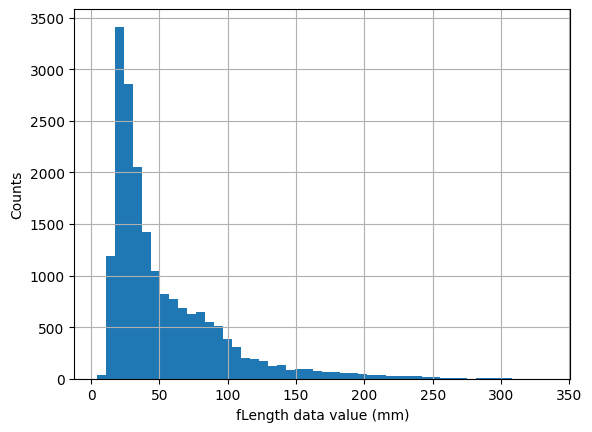

In [ ]:
X['fLength'].hist(bins=50)
plt.xlabel('fLength data value (mm)')
plt.ylabel('Counts')
#plt.title('Histogram of fLength')
plt.show()

Figure 3: A histogram displaying the distribution of the "fLength" feature in the MAGIC X (features) dataset, generated by plotting the frequency of values within 50 bins using the `.hist()` method on the variable column. There is a prominent peak at a relatively low length value, with an exponential dropoff and a tail extending to greater lengths. It would seem that most cosmic ray detections create ellipses on the sensor that are around 25mm long, however a small number of events create a much larger ellipse, which may indicate a different and rarer type of cosmic ray source.

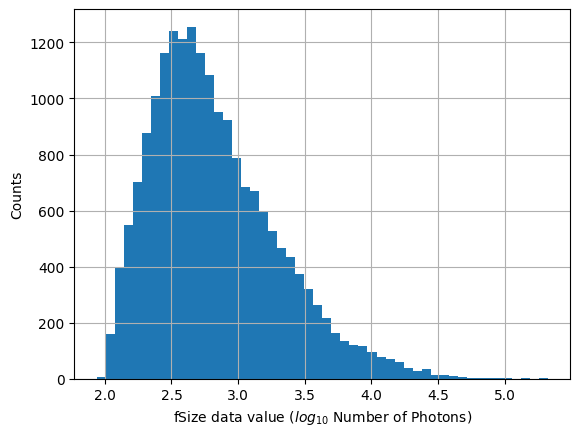

In [ ]:
X['fSize'].hist(bins=50)
plt.xlabel('fSize data value ($log_{10}$ Number of Photons)')
plt.ylabel('Counts')
#plt.title('Histogram of fSize')
plt.show()

Figure 4: A histogram displaying the distribution of the "fSize" feature in the MAGIC X (features) dataset, generated by plotting the frequency of values within 50 bins using the `.hist()` method on the variable column. This distribution looks almost like a bell curve, but skewed towards lower values. It seems that most detections consist of about 125 to 3,000 photons, with a peak at around 400 photons, and a smaller number of detections consisting of greater than 3000 photons.

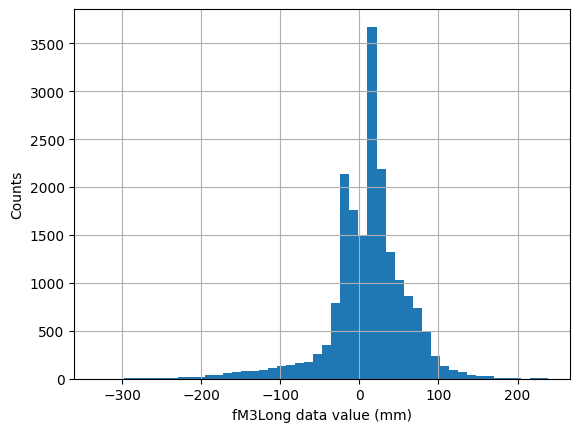

In [ ]:
X['fM3Long'].hist(bins=50)
plt.xlabel('fM3Long data value (mm)')
plt.ylabel('Counts')
#plt.title('Histogram of fM3Long')
plt.show()

Figure 5: A histogram displaying the distribution of the "fM3Long" feature in the MAGIC X (features) dataset, generated by plotting the frequency of values within 50 bins using the `.hist()` method on the variable column. This distribution has seemingly two distinct measurement peaks at -25mm and 25mm, with tails extending out in both positive and negative directions. This seems consistent with the earlier "fLength" histogram.

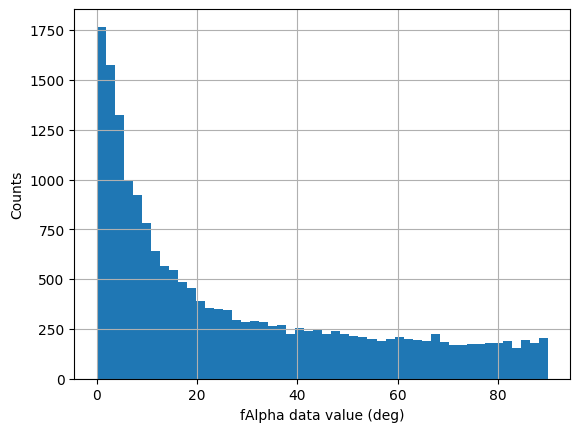

In [ ]:
X['fAlpha'].hist(bins=50)
plt.xlabel('fAlpha data value (deg)')
plt.ylabel('Counts')
#plt.title('Histogram of fAlpha')
plt.show()

Figure 6: A histogram displaying the distribution of the "fAlpha" feature in the MAGIC X (features) dataset, generated by plotting the frequency of values within 50 bins using the `.hist()` method on the variable column. This feature appears to be a measure of the angle that the long axis of the detection elipse makes with the origin (presumably the center point of the detector surface). It looks like a majority of the angles are close to zero degrees from the origin, which would look like radially outward pointing of the ellipses. However there remains a fairly sizable population of ellipses that have a long axis with a significant angle to the center point, all the way up to 90 degrees (perpendicular).

Okay, I think I am satisfied in the data-exploration department. The data seems pretty clean (thank goodness), but the target variable frequency of values is imbalanced, so we will just have to keep that in mind, and account for that with stratification. Let's move on.

## Task 3: Choose Two Models
---

I need to choose two models that can predict from the "Class" variable in the MAGIC dataset whether a detection is a gamma-ray signal ('g') or a background hadron ('h'). The dataset is tabular data consisting of continuous numerical features that describe properties of cosmic ray detections. It would be best for the models I choose to be able to identify nonlinear, interconnected relationships between the features that may influence the probability of detection being one class value or the other. Since the "Class" variable is a categorical data type, I should also choose models that can handle (binary) classification problems.

I will choose a Random Forest Classifier (RF) tree model and a Multi-Layer Perceptron (MLP) neural network model. Both are machine learning models that will be trained on the majority of my MAGIC data, and tested on a smaller subset that is set aside for testing (comparing classification predictions to actual truth).


### **1. Random Forest Classifier Model:**

This is an ensemble method that constructs multiple decision trees during training, uses a random subset of observations/features (aka boostrap - bagging), and outputs the class that the majority of the individual trees think that a given cosmic ray detection belongs to. It uses a random subset of observations/features with a technique known as "boostrap-bagging", where "bootstrapping" samples the data with replacement (intended to reduce variance, not deterministic), and "bagging" means aggregating the bootstrapped results.

Because the model is an ensemble, it is less prone to noise and overfitting, as well as issues faced by indivdual decision trees, such as variance. The random forest model has a built in `features_importances_` attribute that can help reveal which features are most important in classifying the cosmic rays (and will hopfully help me earn some of that sweet, *sweet* extra credit). The combination of many trees can effectively teach the model how to recognize complex patterns in the data, and make more accurate predictions.

### **2. Multi-Layer Perceptron Model:**

This is a type of neural network (NN) that consist of fully connected (dense) layers of perceptrons, analogous to neurons in the brain. This includes an input layer, one or more hidden layers, and an output layer. The interconnected layers transform input data into different dimensions, and can be good at capturing complex, non-linear relationships among input features.

MLP models are useful for binary classification problems, as they can utilize a Sigmoid activation function for the output layer to probabilisticaly sort the outputs into a "category" of either 0 or 1. It can also be configured with a loss function specifically designed to make binary classification decisions. It is for these reasons that I believe an MLP will be well suited for predicting the "class" in the MAGIC dataset.


## Task 4: Preprocess the Data
---

In this task I do the preprocessing step of encoding the target variable (the 'class' column consisting of 'g' and 'h' categories) into numerical values. I perform this with the `LabelEncoder()` class, which encodes 0 for 'g', and 1 for 'h' (we will use this slightly counterintuitive convention through the rest of the assignment). This is necessary because at the end of the day, numbers are the only language that a machine learning model understands.

I split the dataset into a subset for training and a subset to compare/test against. The splitting is 80% train and 20% test as specified by the `test_size` hyperparameter. The proportion of 'g' and 'h' values is maintained in both sets due to the `stratify=y_encoded` hyperparameter. Finally I scale the training and test data using the `StandardScaler()` class. This should make the mean of each variable equal to zero, and the standard deviation is 1. This ensures that each feature is "comparable" and weighs the same when combined with other features.

As a sanity check, I will print the expected result of the target variable encoding, as well as the shapes of the scaled training and testing datasets to make sure that the dimensions match.

In [ ]:
# Encode the target variable ('y')
le = LabelEncoder()
y_encoded = le.fit_transform(y['class'])

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"The original target class values {le.classes_} will be mapped to numerical values {le.transform(le.classes_)}")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

The original target class values ['g' 'h'] will be mapped to numerical values [0 1]
Shape of X_train_scaled: (15216, 10)
Shape of X_test_scaled: (3804, 10)
Shape of y_train: (15216,)
Shape of y_test: (3804,)


## Task 5: Build the Random Forest Model and Choose Hyperparameters
---

I will initialize the Random Forest Classifier model from the sklearn package.

The `n_estimators` hyperparameter represents the number of decision trees in the forest. Generally more trees leads to better performance and less overfitting. I have set it at 200 as a balance between prediction accuracy and training time.

The `random_state` hyperparameter again ensures that the results of this model are reproducable. I have set the value to 42, as before.

The `class_weight` hyperparameter can automatically adjust the weights of categorical classes used in the model's training. Setting the value to 'balanced' makes class weights inversely proportional to their frequencies, and helps prevent the model from becoming biased towards predicting a 'g' classification for MAGIC detections.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model_2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=3)

In [ ]:
RandomForestClassifier?

## Task 6: Train the Random Forest Model
---

This line trains the Random Forest Classifier model on our scaled X features dataset, with the `y_train` dataset being our target classifications.

In [ ]:
rf_model.fit(X_train_scaled, y_train)
#rf_model_2.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## Task 7: Assess the Performance of the Random Forest Model
---

The RF model has been trained, and we can now assess its performance, first by having it make predictions (`y_pred_rf`) on what it thinks the target classification should be ('g' or 'h') based on the scaled X feature set that it just trained on. I then have the RF model make a probability prediction (`y_proba_rf`) of a detection being labelled as the positive class (1 = 'h'), which will allow me to calculate an AUC (area under the curve) score from the sklearn.metrics library. This value will be included in the ROC (Receiver Operating Characteristic) curve that I produce at the end of the assignment to visually compare the performance between my two models.

In [ ]:
# Make predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_2 = rf_model.predict(X_train_scaled)

y_pred_rf_3 = rf_model_2.predict(X_test_scaled)
y_pred_rf_4 = rf_model_2.predict(X_train_scaled)
accuracy_rf_3 = accuracy_score(y_test, y_pred_rf_3)
accuracy_rf_4 = accuracy_score(y_train, y_pred_rf_4)

In [ ]:
accuracy_rf_2 = accuracy_score(y_train, y_pred_rf_2)
print(f"Accuracy: {accuracy_rf_2:.3f}")

print(f"Accuracy: {accuracy_rf_3:.3f}")
print(f"Accuracy: {accuracy_rf_4:.3f}")

Accuracy: 1.000
Accuracy: 0.755
Accuracy: 0.760


The following metrics that I define with `sklearn.metrics` functions are used to evalue the performance of the RF model. `accuracy_rf` is the ratio of total correct predictions to total predictions overall, and quantifies the overall accuracy of the model. The accuracy equation is $\frac{TP+TN}{TP+TN+FP+FN}$.

`precision_rf` is the accuracy rate for which the model predicts positive (1 or hadron) values. The precision equation is $\frac{TP}{TP+FP}$.

`recall_rf` measures the proportion of all positive/hadron values in the test set that were predicted as such. The recall equation is $\frac{TP}{TP+FN}$.

Finally we have the previously-mentioned `roc_auc_rf` score, which is a comprehensive metric for evaluating the model's ability to distinguis between classes, and which will be used later.

In [ ]:
# Model Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"ROC AUC: {roc_auc_rf:.3f}")

Random Forest Model Performance:
Accuracy: 0.884
Precision: 0.891
Recall: 0.763
ROC AUC: 0.939


I will also plot a "confusion matrix" which compares the prediction to the original `y_test` true results of the target class, to visually see how often the RF model made the correct prediction. I will utilize Prof. Bianco's `plot_confusion_matrix` function for instantiating and plotting the confusion matrix, which was introduced in Homework 8.

In [ ]:
# I creaded this function (mostly copied from sklearn examples).
# You can use it to create the confusion matrix, make sure you pass appropriate label

def plot_confusion_matrix(y_true, y_pred,
                          normalize=False,
                          title='', labels=["P", "N"],
                          cmap=plt.cm.bone):
    """
    Plots a confusion matrix.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        normalize (bool, optional): If True, normalize the confusion matrix. Defaults to False.
        title (str, optional): Title of the plot. Defaults to ''.
        labels (list, optional): List of labels for the classes. Defaults to ["P", "N"].
        cmap (matplotlib.colors.Colormap, optional): Colormap for the plot. Defaults to plt.cm.bone.
    """
    if normalize:
          title = title + ' Normalized confusion matrix'
    else:
          title = title + ' Confusion matrix, without normalization'
    # Compute confusion matrix
    if normalize:
      cm = confusion_matrix(y_true, y_pred, normalize='all')
    else:
      cm = confusion_matrix(y_true, y_pred)
    # plot it
    fig, ax = plt.subplots(1, 1)
    fig.subplots_adjust()
    im = ax.imshow(np.rot90(cm), cmap=cmap)
    ax_divider = make_axes_locatable(ax)
    # add an axes to the right of the main axes.
    plt.xticks([0, 1], labels=labels[::-1])

    plt.text(0,1, cm[0,0], ha='center', c="k" if cm[0,0] > 0.1 * cm.sum() else "w")
    plt.text(0,0, cm[0,1], ha='center', c="k" if cm[0,1] > 0.1 * cm.sum() else "w")
    # plt.text(1,1, cm[1,0], ha='center', c="k" if cm[1,0] > 0.1 * cm.sum() else "w")
    plt.text(1,1, cm[1,0], ha='center', c="w") # Force a white font in the top right quadrant
    plt.text(1,0, cm[1,1], ha='center', c="k" if cm[1,1] > 0.1 * cm.sum() else "w")
    plt.ylim(-0.5,1.5)
    plt.yticks([0,1], labels=labels)
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.title(title)
    cax = ax_divider.append_axes("right", size="10%", pad="2%")
    cb = plt.colorbar(im, cax=cax)

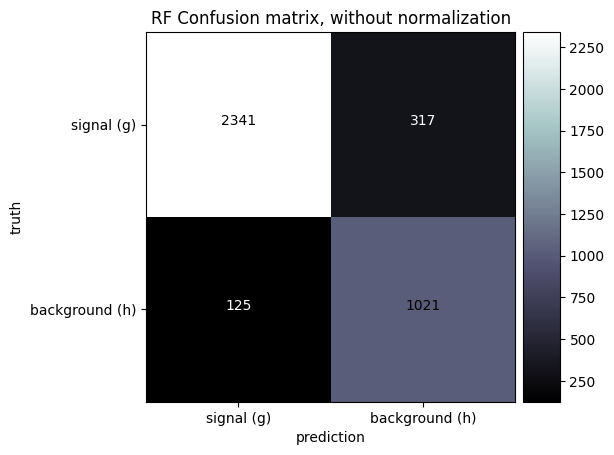

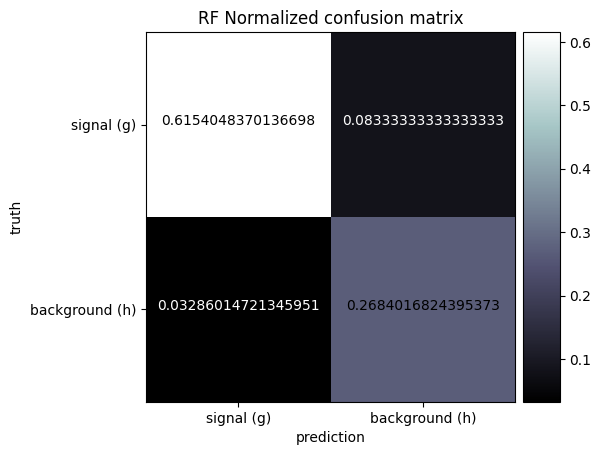

In [ ]:
plot_confusion_matrix(y_test, y_pred_rf, title="RF", labels=["background (h)", "signal (g)"])
plot_confusion_matrix(y_test, y_pred_rf, normalize=True, title="RF", labels=["background (h)", "signal (g)"])

Figure 7: A pair of "confusion" matrices for the Random Forest Classifier model. The upper matrix shows the raw prediction counts, and the lower matrix shows the normalized values, indicating the proportion of each truth/prediction outcome relative to the whole. The matrices visually represent the model's performance in classifying gamma-ray signals ('g') and background hadrons ('h'), with 'g' mapped to 0 and 'h' mapped to 1. In both matrices, the top left quadrant shows true negatives (correctly classified 'g'), bottom right shows true positives (correctly classified 'h'), top right shows false positives (incorrectly classified 'g' as 'h'), and bottom left shows false negatives (incorrectly classified 'h' as 'g'). By summing the numbers of correct predictions, we can verify that the RF model's accuracy is indeed roughly 88%. We also verify that the testing subset has the same 2:1 split between 'g' and 'h' as the full dataset of y-target classes, meaning that the stratification worked.

## Task 8: Build the MLP Model and Choose Hyperparameters
---

(mention Sigmoid activation function)

I define and compile the Multi-Layer Perceptron model, using the Keras API in the TensorFlow library. `keras.Sequential([...])` means that the layers are stacked one after the other. The first parameter of this function defines the `Input` layer, which is given the scaled X training data and its dimensions. Next comes two alternations between `Dense` (fully interconnected) layers and `Dropout` layers, followed by a final `Dense` layer which serves as the output layer.

 I have configured the `Dense` layers to go from 64 to 32 to 1 nueron(s), for which I intended to funnel the neurons into outputting a final binary value. The activation function is the commonly used 'ReLu' (Recitified Linear Unit), which is meant to help the model learn non-linear relationships, excpet for the last layer, which uses the 'sigmoid' activation function. This is an s-shaped function which squashes the output between 0 and 1. The ReLu equation is $max(0,x)$, and the sigmoid equation is $\frac{1}{1+e^{-x}}$.

 I have configured the `Dropout` layers to randomly drop 20% of the neurons from the previous layer. This technique occurs often in the literature, and is used to prevent neurons from becoming too co-dependent, and helps reduce overfitting.

 The hyperparameters that I use when compiling the model include `optimizer='adam'`, which is a commonly used algorithm that is efficient at updating the neuron weights. `loss='binary_crossentropy'` was chosen because it is supposed to be effective at tracking the performance (loss) for binary classification tasks, which is what we are dealing with. Finally the `metrics=['accuracy']` hyperparameter allows for the model's accuracy metric to be tracked and reported.

In [ ]:
mlp_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)), # Input layer
    layers.Dense(64, activation='relu'),            # Hidden layer 1
    layers.Dropout(0.2),                            # Dropout layer
    layers.Dense(32, activation='relu'),            # Hidden layer 2
    layers.Dropout(0.2),                            # Dropout layer
    layers.Dense(1, activation='sigmoid')           # Output layer for binary classification
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 9: Train the MLP Model
---


Training the MLP model can run for many epochs (a long time) if we let it. Before we start the training, it is useful to define a 'callback' instance that will monitor the `'val_loss'` training metric, and causes an early stop to occur when the model stops learning (the loss value does not drop for 10 consecutive turns, as defined by the `patience=10` parameter), as a way to avoid overfitting. The `restore_best_weights=True` arguement retains the weights from the epoch with the lowest validation loss, which might not necessarily be the very last epoch before stopping.

It is also good to have an early stopping mechanism standing by to conserve computational resources, because this particular training that I'm about to do is the most computationally expensive task in this assignment. Whenever I run this kind of operation, I get a little nervous that some Google engineer or the ghost of the penguin that I just killed will come after me.

In [ ]:
callback = EarlyStopping(monitor='val_loss',
                         patience=10,
                         #min_delta=0.0001,
                         restore_best_weights=True)

This is the code that actually trains the MLP. I feed it the scaled X features and y-target data, and the maximum number of epochs that I'll allow the training to run for. Other hyperparameters include the `batch_size=16` which defines the size of the data subsets evaluated in each epoch, and has implications on the speed of the training smoothness of the loss gradient. The `validation_data` paramter allows me to specify the data I wish for the model to compare against during training, which I set as the same testing subset that I defined at the start. `verbose=1` allows me to see the progress bars for each epoch as they occur, along with the training and validation metrics. Finally the `callbacks` arguement activates my early stopping mechanism for the training.

In [ ]:
history = mlp_model.fit(X_train_scaled,
                    y_train,
                    epochs=150,
                    batch_size=16,
                    #validation_split=0.2,
                    validation_data=[X_test_scaled, y_test],
                    verbose=1,
                    callbacks=[callback])

Epoch 1/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7727 - loss: 0.4821 - val_accuracy: 0.8520 - val_loss: 0.3514
Epoch 2/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8370 - loss: 0.3858 - val_accuracy: 0.8683 - val_loss: 0.3321
Epoch 3/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8401 - loss: 0.3684 - val_accuracy: 0.8704 - val_loss: 0.3219
Epoch 4/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8531 - loss: 0.3525 - val_accuracy: 0.8720 - val_loss: 0.3140
Epoch 5/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8599 - loss: 0.3449 - val_accuracy: 0.8785 - val_loss: 0.3127
Epoch 6/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8570 - loss: 0.3431 - val_accuracy: 0.8772 - val_loss: 0.3050
Epoch 7/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8532 - loss: 0.3442 - val_accuracy: 0.8746 - val_loss: 0.3057
Epoch 8/150
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8586 - loss: 0.3412 - val_accu

I will generate a nifty "learning curve" plot that visualizes the progress of my MLP model. It tracks how the 'loss' and 'validation loss' metrics change over the course of the training process.

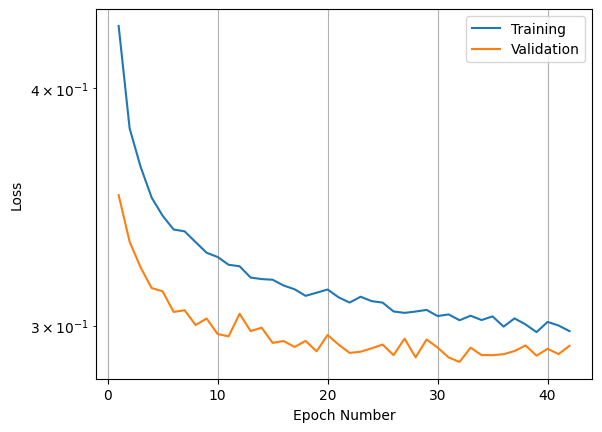

In [ ]:
num_epochs = len(history.history['loss'])
epochs_range = range(1, num_epochs + 1)

plt.plot(epochs_range, history.history['loss'], label="Training")
plt.plot(epochs_range, history.history['val_loss'], label="Validation")
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
#plt.title('MLP Loss vs. Number of Epochs')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

Figure 8: A plot of the loss value measured by the scaled X features's Training and Validation data after being trained by a Multi-Layer Perceptron (MLP) model over a series of epochs (iterations). In this particular instance, the `EarlyStopping` mechanism stopped the training after 42 epochs (what a coincidence). We see that both the 'loss' and 'val_loss' metrics dropped rapidly at first, then began to flatten out at around 15 epochs in. By the end, the model had just about ceased learning, and the Training loss ended higher than the Validation loss, so overfitting should not be an issue.

## Task 10: Assess the Performance of the MLP Model
---


I will make predictions using the trained MLP model on the scaled test data. Since the output layer uses a sigmoid activation, `model.predict()` will return probabilities, which need to be converted to binary class labels (0 or 1) using a threshold of 0.5 for `y_pred_mlp`. The raw probabilities for the positive class will be stored in `y_proba_mlp`.

Next I will again define some metrics that evalute the performance of the MLP model and the precision and accuracy of its predictions. These are the same sorts of metrics that I evaluated the Random Forest model by, and their definitions are the same.

In [ ]:
y_proba_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions and probabilities generated for Keras MLP model.


In [ ]:
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)

print("Keras MLP Model Performance:")
print(f"Accuracy: {accuracy_mlp:.3f}")
print(f"Precision: {precision_mlp:.3f}")
print(f"Recall: {recall_mlp:.3f}")
print(f"ROC AUC: {roc_auc_mlp:.3f}")

Keras MLP Model Performance:
Accuracy: 0.883
Precision: 0.896
Recall: 0.755
ROC AUC: 0.939


I will plot another "confusion matrix" pair which will compare the predictions to the original `y_test` true results of the target class, to visually see how often the MLP model made the correct prediction. I will again utilize the `plot_confusion_matrix` function for this.

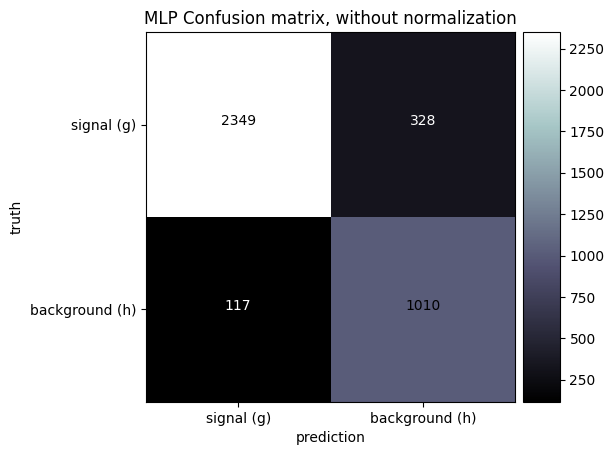

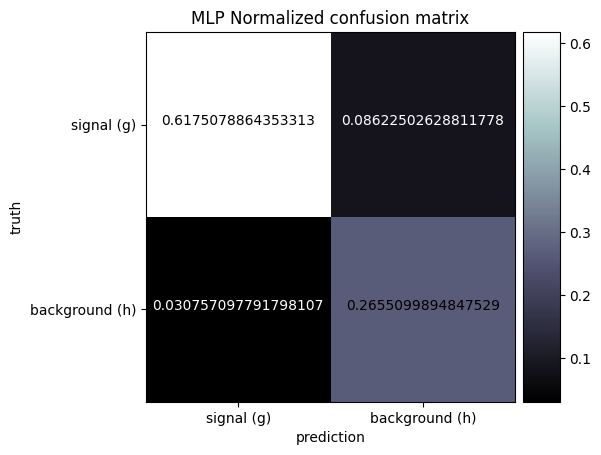

In [ ]:
plot_confusion_matrix(y_test, y_pred_mlp, title="MLP", labels=["background (h)", "signal (g)"])
plot_confusion_matrix(y_test, y_pred_mlp, normalize=True, title="MLP", labels=["background (h)", "signal (g)"])

Figure 9: A pair of "confusion" matrices for the MLP model. The upper matrix shows the raw prediction counts, and the lower matrix shows the normalized values, indicating the proportion of each truth/prediction outcome relative to the whole. The matrices visually represent the model's performance in classifying gamma-ray signals ('g') and background hadrons ('h'), with 'g' mapped to 0 and 'h' mapped to 1. In both matrices, the top left quadrant shows true negatives (correctly classified 'g'), bottom right shows true positives (correctly classified 'h'), top right shows false positives (incorrectly classified 'g' as 'h'), and bottom left shows false negatives (incorrectly classified 'h' as 'g'). By summing the numbers of correct predictions, we can verify that the MLP model's accuracy is indeed roughly 88%. We also verify that the testing subset has the same 2:1 split between 'g' and 'h' as the full dataset of y-target classes, meaning that the stratification worked.

## Task 11: Compare the Models' Performance
---

The final primary task is to compare how the performance of my two models stacks up against each other. For this, I will plot the aforementioned Receiver Operating Characteristic (ROC) curve, that for each model visually represents the trade-off between the true positive rate and the false positive rate at various classification thresholds.

The `roc_curve` function from `sklearn.metrics` compares our test datset again the earlier predicted positive probabilty score, and returns a False Positive Rate (`fpr_`), a True Positive Rate (`tpr_`), and a threshold value that we don't care about, so we just use an underscore. We do this for both the RF and the MLP models. The tpr and fpr arrays are plotted against each other to form the ROC curve.

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

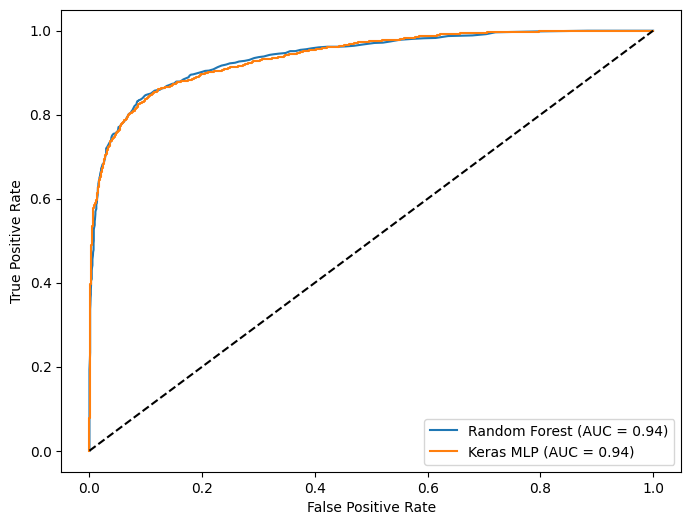

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {roc_auc_mlp:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('ROC Curve: Random Forest vs. MLP')
plt.legend(loc='lower right')
plt.show()

Figure 10: An ROC (Receiver Operating Characteristic) curve that compares the True Positive Rate (TPR) and False Positive Rate (FPR) at various classification thresholds. This allows a comprehensive view of a model's performance across different levels of sensitivity. The result from both the Random Forest and the MLP models are plotted together here, and we see that they nearly overlap, and both have an AUC score of about 0.94, which tells us that the two models as they are presently configured have very similar performance for the MAGIC dataset, although the Random Forest's performance may be ever-so-slightly better.

### Discussion:
Based on my analysis, both the Random Forest (RF) and Multi-Layer Perceptron (MLP) models demonstrated fairly strong and quite competitive performance on the MAGIC dataset. In their present configurations, both models achieved a ROC AUC of around 0.939. With this near-identical AUC score, coupled with the overlapping ROC curves, both models appear to be pretty much equally effective at distinguishing between gamma-ray signals and background hadrons for this specific dataset. The RF model is strong due to being an ensemble, making it robust against overfitting (even without an early stopping mechanism) and capable of implicitly handling complex feature interactions, as well as providing feature importance. The MLP, on the other hand, excels at learning intricate non-linear patterns within the data, and its architecture can be further scaled and made more complex in terms of its hyperparameters. I suspect with more fine-tuning, the MLP model would be able to surpass the RF's performance.

Both models seemed to be very much appropriate for this particular dataset, which consists of tabular data with continuous numerical features and a binary classification target. Both models seem designed with this type of data in mind as one potential use case. As the RF and MLP both seem to perform similarly, the choice to use either one may come down to other factors. Random Forests tend to be more interpretable (such as through feature importance, which we'll see) and often quicker and cheaper to train, whereas MLPs tend to require more tuning and computational resources, but can offer greater flexibility in architecture and should have the potential to uncover deeper patterns in data, making them suitable for scenarios where marginal performance gains are desired.

## Extra Credit: A Feature Analysis of the Random Forest Model
---

I can use the `feature_importances_` attribute of the Random Forest model to extract the relative importance of each feature (a number from 0 to 1). I will then plot a bar graph of the features ordered by their proportional weight, similarly to how I did in Homework 8.

In [ ]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Sort the features by importance
sorted_indices = np.argsort(feature_importances)

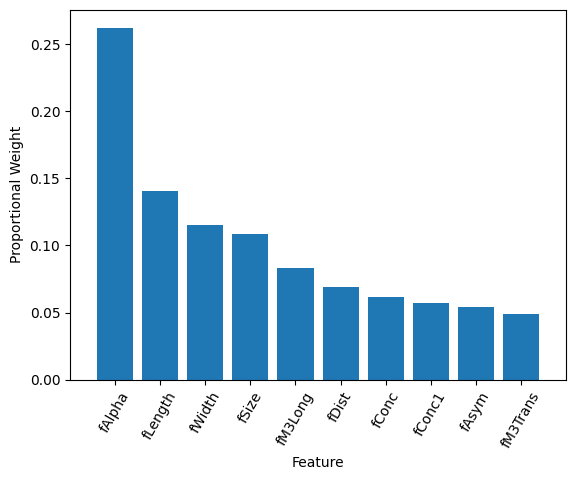

In [ ]:
# Plot the feature importances
plt.figure()
#plt.title("Feature importances RF")
plt.bar(range(len(sorted_indices)), feature_importances[sorted_indices[::-1]], align="center")
plt.xticks(range(len(sorted_indices)), X.iloc[:, sorted_indices[::-1]].columns, rotation=60)
plt.xlim([-1, len(sorted_indices)])
plt.xlabel("Feature")
plt.ylabel("Proportional Weight")
plt.show()

Figure 11: A bar graph of feaure importances for the Random Forest Classifier Model. The individual features of the X dataframe are displayed with their proportional weights in terms of the influence they had in determining the Random Forest's predictions for how detections should be classified ('g' or 'h'), as obtained by using the `feature_importances_` attribute of the model. From the plot, we see that the `fAlpha` feature had by far the most influence at over 25% of the total weight, with `fM3Trans` being the least influential. This tells me that the angle that the long axis of the cosmic ray clusters make on the detector relative to the center of the detect *do* in fact matter in determining whether that cluster comes from a gamma ray! On the other hands, features suc as the symmetery of the oval clusters is not as important.